Inputs shape: (46, 8)
Outputs shape: (46,)
First 20 rows of raw data:
    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6  hype-para-7  hype-para-8    output  source
41     0.121212     0.121212     0.000000     0.000000     0.363636     0.727273     0.484849     0.848484  9.609759  week-2
14     0.056447     0.065956     0.022929     0.038786     0.403935     0.801055     0.488307     0.893085  9.598482    file
42     0.043751     0.045306     0.045319     0.033695     0.337741     0.771663     0.496881     0.775992  9.587655  week-3
45     0.010000     0.661416     0.010000     0.212650     0.889104     0.671374     0.010000     0.450308  9.567349  week-6
40     0.000000     0.125000     0.000000     0.000000     0.375000     0.750000     0.500000     0.875000  9.565800  week-1
26     0.192640     0.630677     0.416796     0.490529     0.796086     0.654567     0.276241     0.295518  9.344274    file
44     0.000000     0.000000     0.000000     0.845416 

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/models/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


Epoch 1/500, Train Loss: 1.025156, Val Loss: 1.210244
Epoch 50/500, Train Loss: 0.069048, Val Loss: 0.080552
Early stopping at epoch 94, best val_loss=0.068634


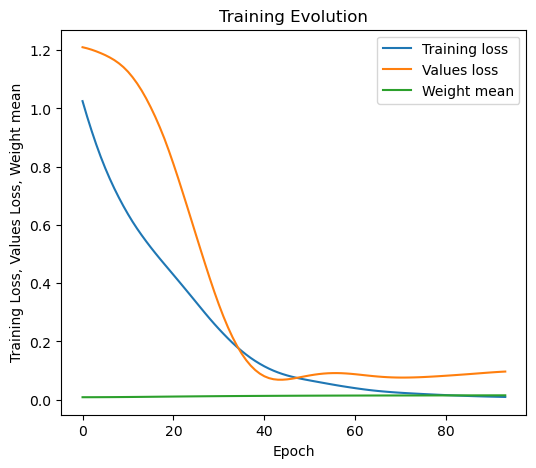

sample_strategy=lhs, Final sample shape: (100, 8)
Filtered 35 candidates using filter_strategy='good'
Predictions range (scaled): -0.3516 to 1.2970
Inverse-transforming predictions to raw units
Predictions range (raw): 7.6623 to 9.3831
Total number of points to evaluate: 6
{'method': 'PI', 'xi': 0.0, 'kappa': None, 'x': array([0.3038676 , 1.0659107 , 0.27949188, 0.1136905 , 0.98047112,
       0.7234944 , 0.1764721 , 0.67240149]), 'score': 0.34412444337348636, 'dim': 8, 'predicted_y': 9.383125}
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.3038676 , 1.0659107 , 0.27949188, 0.1136905 , 0.98047112,
       0.7234944 , 0.1764721 , 0.67240149]), 'score': 0.3373476787232973, 'dim': 8, 'predicted_y': 9.383125}
{'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([0.50289215, 0.53518209, 0.02592663, 0.20563523, 0.30758594,
       0.55455551, 0.01079391, 0.88520987]), 'score': 0.15311981562542643, 'dim': 8, 'predicted_y': 9.210093}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': ar

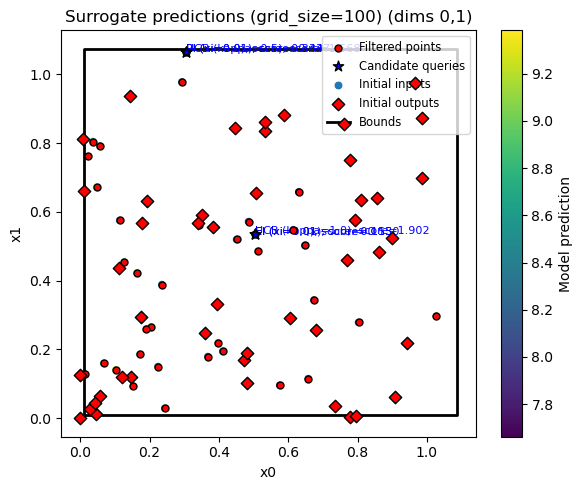

<Figure size 600x500 with 0 Axes>

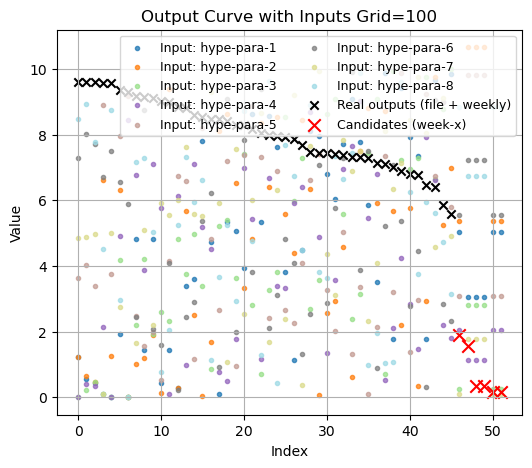

Saved dataframe to: results/run_2025-12-14 13-40-42/df_grid_100_stride6_median_max_raw_lr0.001_ep600.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 1.0, 'x': array([0.50289215, 0.53518209, 0.02592663, 0.20563523, 0.30758594,
       0.55455551, 0.01079391, 0.88520987]), 'score': 1.9016630521099869, 'dim': 8, 'predicted_y': 9.210093}
    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6  hype-para-7  hype-para-8    output  source  output-scaled
0      0.121212     0.121212     0.000000     0.000000     0.363636     0.727273     0.484849     0.848484  9.609759  week-2      10.000000
1      0.056447     0.065956     0.022929     0.038786     0.403935     0.801055     0.488307     0.893085  9.598482    file       9.988265
2      0.043751     0.045306     0.045319     0.033695     0.337741     0.771663     0.496881     0.775992  9.587655  week-3       9.976999
3      0.010000     0.661416     0.010000     0.212650     0.889104     0.671374     0.010000 

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (6, 5)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))